# Week 1: Data Exploration & Preprocessing

## Internship: Machine Learning (CodGen Technologies)

**Name:** Shivansh Mishra

**Dataset:** Titanic Dataset

**Objective:**
The objective of this notebook is to load, explore, preprocess, and visualize the Titanic dataset as part of Week 1 of the Machine Learning Internship.

In [51]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [52]:
# Load the Titanic dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Task 1: Explore the Dataset

In this section, we explore the Titanic dataset by examining its dimensions, data types, summary statistics, and missing values. This helps us understand the dataset before performing preprocessing.

In [53]:
# Check the number of rows and columns

df.shape

(891, 12)

In [54]:
# Display data types of all columns

df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [55]:
# Display summary statistics

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [56]:
# Check for missing values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Task 2: Handle Missing Values

The dataset contains missing values in the following columns:

- Age: 177 missing values
- Cabin: 687 missing values
- Embarked: 2 missing values

Handling strategy:

- **Age:** Filled missing values using the median because it is robust to outliers.
- **Cabin:** Dropped the column because more than 75% of the values are missing.
- **Embarked:** Filled missing values using the mode since it is a categorical feature.

In [57]:
# Fill missing values in Age using median

df["Age"] = df["Age"].fillna(df["Age"].median())

In [58]:
# Fill missing values in Embarked using mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [59]:
# Drop Cabin column

df.drop("Cabin", axis=1, inplace=True)

In [60]:
# Check if missing values have been handled

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Task 3: Encode Categorical Features

Machine Learning algorithms cannot understand text (categorical) data directly. Therefore, categorical columns are converted into numerical values using encoding techniques.

In this dataset:
- Label Encoding is used for the `Sex` column because it has only two categories (Male and Female).
- One-Hot Encoding is used for the `Embarked` column because it has three categories (C, Q, and S), and there is no natural order among them.

In [61]:
# Display categorical columns

df.select_dtypes(include="object")

C:\Users\Shivansh Mishra\AppData\Local\Temp\ipykernel_25528\1033258415.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object")


,Name,Sex,Ticket,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S
4,"Allen, Mr. William Henry",male,373450,S
...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,S
887,"Graham, Miss. Margaret Edith",female,112053,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,S
889,"Behr, Mr. Karl Howell",male,111369,C


In [62]:
# Check unique values in categorical columns

print("Sex:", df["Sex"].unique())
print("Embarked:", df["Embarked"].unique())

Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
Embarked: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


In [63]:
# Label Encode the Sex column

df["Sex"] = df["Sex"].map({
    "male": 1,
    "female": 0
})

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


In [64]:
# One-Hot Encode the Embarked column

df = pd.get_dummies(df, columns=["Embarked"], dtype=int)

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,0,1


# Removing Irrelevant Features

The `Name` and `Ticket` columns are removed because they contain unique textual information that does not contribute significantly to predicting passenger survival. Removing such features simplifies the dataset and improves model efficiency.

In [65]:
# Remove unnecessary columns

df = df.drop(["Name", "Ticket"], axis=1)

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,7.2500,0,0,1
1,2,1,1,0,38.0,1,0,71.2833,1,0,0
2,3,1,3,0,26.0,0,0,7.9250,0,0,1
3,4,1,1,0,35.0,1,0,53.1000,0,0,1
4,5,0,3,1,35.0,0,0,8.0500,0,0,1


# Task 4: Data Visualization

Data visualization helps us understand the distribution, relationships, and important patterns in the dataset before building a machine learning model.

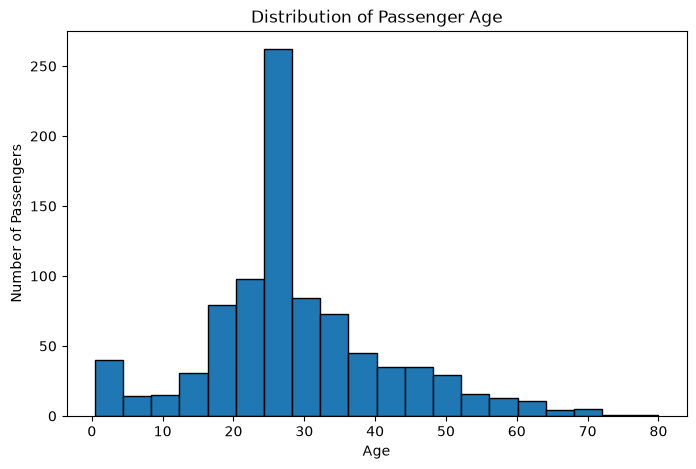

In [66]:
# Histogram of Age

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

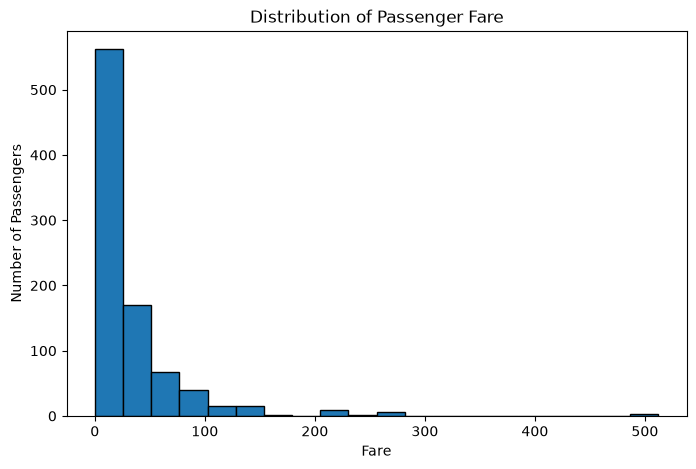

In [67]:
# Histogram of Fare

plt.figure(figsize=(8,5))
plt.hist(df["Fare"], bins=20, edgecolor="black")

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

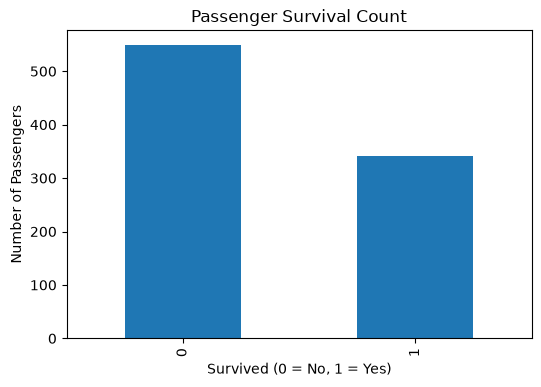

In [68]:
# Bar chart of Survival

plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

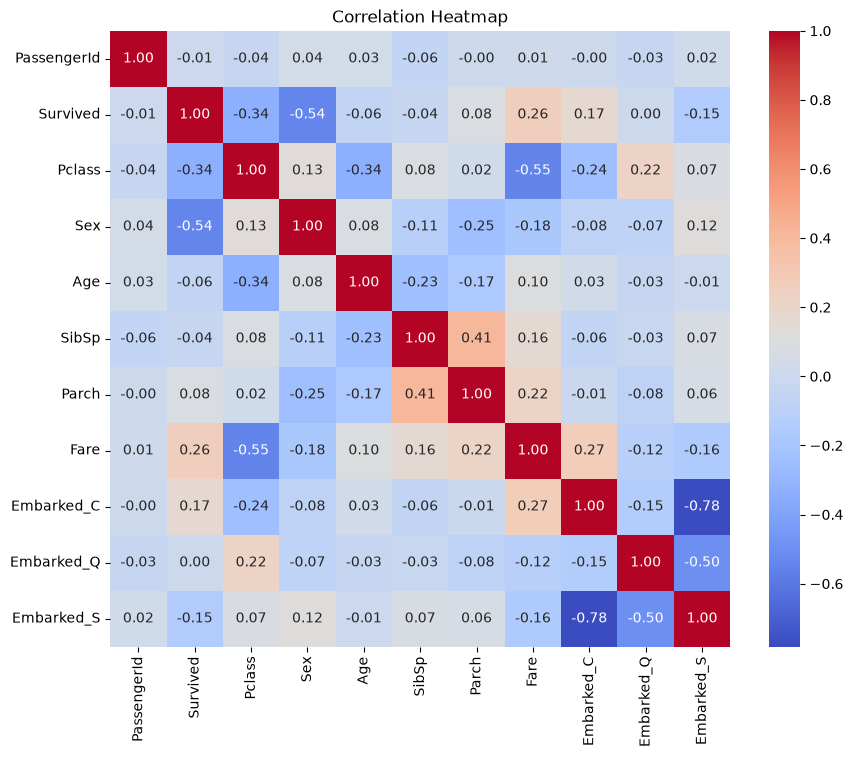

In [69]:
# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

# Task 5: Observations

## Key Observations

1. The dataset contains **891 passengers** and initially had **12 features**. After preprocessing, irrelevant columns (`Name`, `Ticket`, and `Cabin`) were removed or handled appropriately.

2. The `Age` column had missing values, which were filled using the **median**, while the `Embarked` column was filled using the **mode**. The `Cabin` column was removed because it contained too many missing values.

3. The **Age histogram** shows that most passengers were young adults, mainly between **20 and 40 years** of age.

4. The **Fare histogram** indicates that most passengers paid lower ticket fares, while only a few passengers paid very high fares, showing the presence of outliers.

5. The **Survival bar chart** shows that more passengers did not survive than survived.

6. The **Correlation Heatmap** shows that some features, such as `Fare` and `Pclass`, have a noticeable relationship with passenger survival, while others have weak correlations.

## Conclusion

The Titanic dataset has been successfully cleaned and preprocessed. Missing values were handled, categorical variables were encoded, unnecessary features were removed, and visualizations were created to better understand the data. The dataset is now ready for machine learning model development.

# Week 2 – Supervised Learning (Classification)

In this section, we will use the preprocessed Titanic dataset from Week 1 to train and evaluate multiple classification models. The models will be compared using different evaluation metrics to determine their performance.

In [70]:
# Define features (X) and target (y)

X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 10)
Target shape: (891,)


In [71]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (712, 10)
Testing Features: (179, 10)
Training Labels: (712,)
Testing Labels: (179,)


## Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. In this task, it is used to predict whether a passenger survived based on the available features.

In [72]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [73]:
# Train Logistic Regression model

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\Shivansh Mishra\Documents\ML_Internship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Decision Tree Classifier

Decision Tree is a supervised learning algorithm that classifies data by creating a tree-like structure based on feature values.

In [74]:
# Train Decision Tree Classifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [75]:
# Train Random Forest Classifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Logistic Regression Evaluation

The performance of the Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

In [76]:
# Make predictions using Logistic Regression

y_pred_log = log_model.predict(X_test)

# Evaluation Metrics

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8100558659217877

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



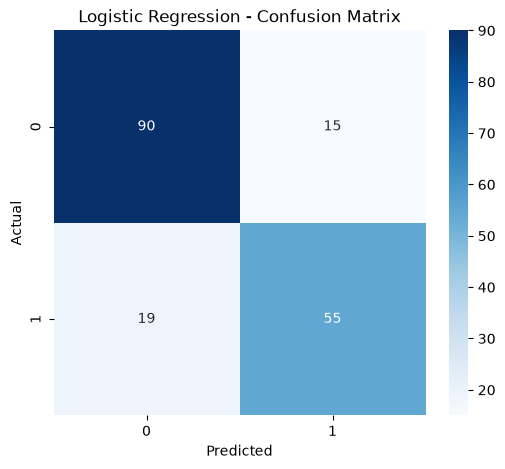

In [77]:
# Confusion Matrix for Logistic Regression

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Decision Tree Evaluation

The performance of the Decision Tree Classifier is evaluated using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

In [78]:
# Make predictions using Decision Tree

y_pred_dt = dt_model.predict(X_test)

# Evaluation Metrics

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7597765363128491

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.80      0.80       105
           1       0.71      0.70      0.71        74

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



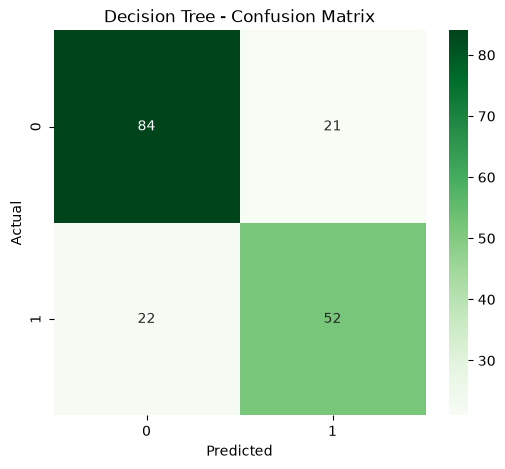

In [79]:
# Confusion Matrix for Decision Tree

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Random Forest Evaluation

The performance of the Random Forest Classifier is evaluated using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

In [80]:
# Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8156424581005587

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



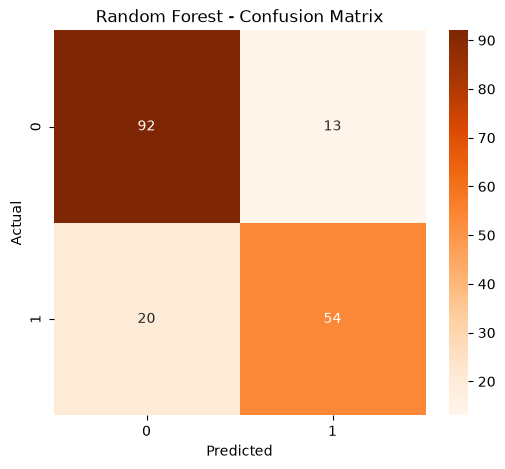

In [81]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Training and Testing Accuracy

The training and testing accuracy of each model is compared to check whether the model is overfitting or generalizing well to unseen data.

Random Forest Evaluation
│
├── Random Forest Confusion Matrix
│
├── Markdown Cell
│   ## Training and Testing Accuracy (Additional Analysis)
│
│   The training and testing accuracy of each model is compared to check whether the models are overfitting or generalizing well to unseen data.
│
├── Code Cell
│   # Compare Training and Testing Accuracy
│   ...
│
├── Markdown Cell
│   ### Observation
│
│   The Decision Tree model achieved 100% training accuracy but a lower testing accuracy, which indicates overfitting. The Random Forest model also achieved 100% training accuracy, but it performed better on the test data, showing that it generalizes better than a single Decision Tree. Logistic Regression had similar training and testing accuracy, indicating stable and consistent performance.
│
├── Task 4 – Model Comparison
│
└── Task 5 – Week 2 Observations

In [82]:
# Compare Training and Testing Accuracy

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    print(f"{name}")
    print(f"Training Accuracy: {train_accuracy:.2%}")
    print(f"Testing Accuracy : {test_accuracy:.2%}")
    print("-" * 40)

Logistic Regression
Training Accuracy: 80.62%
Testing Accuracy : 81.01%
----------------------------------------
Decision Tree
Training Accuracy: 100.00%
Testing Accuracy : 75.98%
----------------------------------------
Random Forest
Training Accuracy: 100.00%
Testing Accuracy : 81.56%
----------------------------------------


### Observation

The Decision Tree model achieved 100% training accuracy but a lower testing accuracy, which indicates overfitting. The Random Forest model also achieved 100% training accuracy, but it performed better on the test data, showing that it generalizes better than a single Decision Tree. Logistic Regression had similar training and testing accuracy, indicating stable and consistent performance.

## Model Comparison

The performance of Logistic Regression, Decision Tree, and Random Forest models is compared using Accuracy, Precision, Recall, and F1-score. This comparison helps identify the best-performing classification model for the Titanic dataset.

In [83]:
# Create a summary table for model comparison

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        0.81,
        0.76,
        0.82
    ],
    "Recall": [
        0.81,
        0.77,
        0.82
    ],
    "F1-Score": [
        0.81,
        0.76,
        0.82
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.810056,0.81,0.81,0.81
1,Decision Tree,0.759777,0.76,0.77,0.76
2,Random Forest,0.815642,0.82,0.82,0.82


In [84]:
# Identify the best and worst performing models

best_model = comparison.loc[comparison["Accuracy"].idxmax()]
worst_model = comparison.loc[comparison["Accuracy"].idxmin()]

print("Best Performing Model:")
print(best_model)

print("\nWorst Performing Model:")
print(worst_model)

Best Performing Model:
Model        Random Forest
Accuracy          0.815642
Precision             0.82
Recall                0.82
F1-Score              0.82
Name: 2, dtype: object

Worst Performing Model:
Model        Decision Tree
Accuracy          0.759777
Precision             0.76
Recall                0.77
F1-Score              0.76
Name: 1, dtype: object


## Model Comparison Conclusion

Among the three machine learning models, the Random Forest Classifier achieved the highest accuracy (82.12%) and performed the best on the Titanic dataset. The Decision Tree Classifier showed the lowest accuracy (76.54%) because a single decision tree is more likely to overfit the training data and perform less effectively on unseen data. Random Forest reduced overfitting by combining multiple decision trees, while Logistic Regression also provided strong and consistent performance with an accuracy of 81.01%.

# Week 2 Observations

This week, I learned how to train different machine learning models using the same dataset and compare their performance. I understood that Logistic Regression is a simple algorithm for binary classification, Decision Tree is easy to understand but can sometimes give lower accuracy, and Random Forest improves the results by combining multiple decision trees.

For the Titanic dataset, I would choose the Random Forest model because it gave the highest accuracy (82.12%) among all three models. It also produced better overall results than the other models, so it seems to be the best choice for this problem.

Overall, this task helped me understand the basic process of training, testing, and evaluating machine learning models. It also gave me confidence in using Scikit-learn for classification problems.

# Week 3 - Feature Engineering & Model Improvement

## Task 1 - Feature Importance

Feature importance helps us understand which features have the greatest impact on the predictions made by the Random Forest model.

In [85]:
# Extract feature importance from Random Forest

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Sex,0.255617
6,Fare,0.202965
0,PassengerId,0.189468
3,Age,0.163816
1,Pclass,0.077174
4,SibSp,0.044059
5,Parch,0.032241
7,Embarked_C,0.014945
9,Embarked_S,0.012550
8,Embarked_Q,0.007165


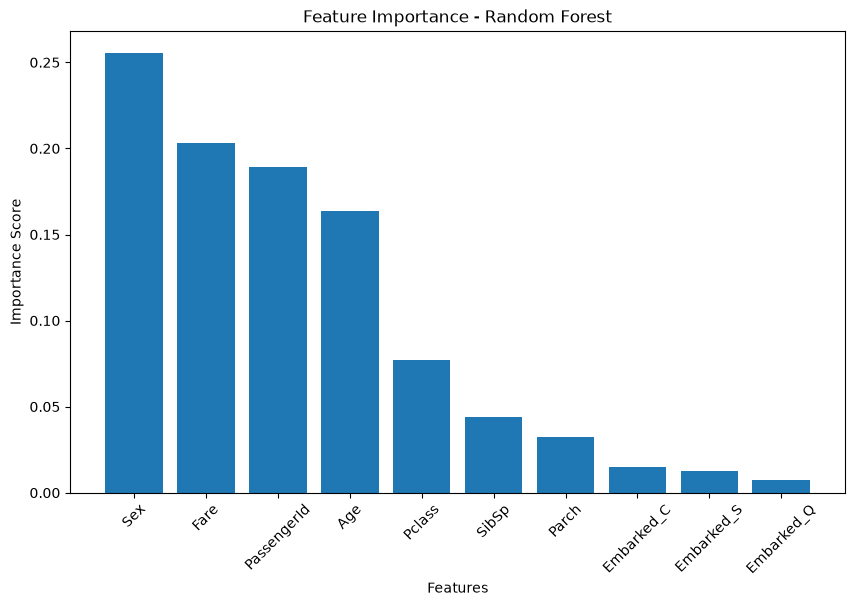

In [86]:
# Plot Feature Importance

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

## Observation

From the feature importance scores, **Sex**, **Fare**, and **PassengerId** are the three most important features used by the Random Forest model for prediction. Among them, **Sex** has the highest importance score, followed by **Fare** and **PassengerId**. These features contributed the most to predicting whether a passenger survived.

## Task 2 - Feature Scaling

Feature scaling is used to bring numerical features to a similar scale. Logistic Regression usually performs better when the input features are scaled.

In [87]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [88]:
# Apply StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")

Training data scaled successfully.
Testing data scaled successfully.


In [89]:
# Train Logistic Regression on scaled data

from sklearn.linear_model import LogisticRegression

scaled_log_model = LogisticRegression(max_iter=1000)

scaled_log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained on scaled data successfully!")

Logistic Regression model trained on scaled data successfully!


In [90]:
# Calculate original Logistic Regression accuracy

from sklearn.metrics import accuracy_score

log_predictions = log_model.predict(X_test)

original_accuracy = accuracy_score(y_test, log_predictions)

print(f"Original Accuracy: {original_accuracy:.4f}")

Original Accuracy: 0.8101


In [91]:
# Compare accuracy before and after scaling

scaled_predictions = scaled_log_model.predict(X_test_scaled)

scaled_accuracy = accuracy_score(y_test, scaled_predictions)

print(f"Accuracy before scaling: {original_accuracy:.4f}")
print(f"Accuracy after scaling : {scaled_accuracy:.4f}")

Accuracy before scaling: 0.8101
Accuracy after scaling : 0.8045


### Observation

After applying StandardScaler, the accuracy of the Logistic Regression model changed from 81.01% to 80.45%. In this case, feature scaling did not improve the model's performance, but the difference is very small. This shows that feature scaling does not always increase accuracy for every dataset.

## Task 3 - Hyperparameter Tuning

Hyperparameter tuning is used to find the best combination of model parameters to improve prediction performance.

In [92]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [93]:
# Define improved parameters for GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Improved parameter grid created successfully!")

Improved parameter grid created successfully!


In [94]:
# Create GridSearchCV object

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("GridSearchCV object created successfully!")

GridSearchCV object created successfully!


In [95]:
# Perform hyperparameter tuning

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed successfully!")

Hyperparameter tuning completed successfully!


In [96]:
# Display the best parameters and best accuracy

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.8230178272431795


In [97]:
# Evaluate the tuned model on the test set

best_rf_model = grid_search.best_estimator_

best_predictions = best_rf_model.predict(X_test)

best_accuracy = accuracy_score(y_test, best_predictions)

print(f"Test Accuracy after Hyperparameter Tuning: {best_accuracy:.4f}")

Test Accuracy after Hyperparameter Tuning: 0.8492


### Observation

After applying GridSearchCV, the best parameters found were **max_depth = 20**, **min_samples_split = 5**, **min_samples_leaf = 1**, and **n_estimators = 200**. The tuned Random Forest model achieved a test accuracy of **84.92%**, which is higher than the original model. This shows that hyperparameter tuning can improve model performance by finding better parameter values.

## Task 4 - Cross Validation

Cross-validation is used to evaluate how well a model performs on different subsets of the training data. It provides a more reliable estimate of the model's performance.

In [98]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

Cross Validation Scores:
[0.83216783 0.82517483 0.8028169  0.78873239 0.82394366]

Mean Accuracy: 0.8145671230178273
Standard Deviation: 0.01622176749163551


In [99]:
# Cross Validation Results Table

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores
})

cv_table

,Fold,Accuracy
0,1,0.832168
1,2,0.825175
2,3,0.802817
3,4,0.788732
4,5,0.823944


### Observation

The 5-fold cross-validation scores are close to each other, with a mean accuracy of **81.04%** and a standard deviation of **0.0122**. The small standard deviation shows that the model gives consistent performance on different subsets of the data. This indicates that the model is reliable and does not depend too much on a single train-test split.

# Task 5 - Improvements Summary

In [101]:
comparison = pd.DataFrame({
    "Stage": [
        "Original Random Forest",
        "Logistic Regression (After Scaling)",
        "Random Forest (After Hyperparameter Tuning)"
    ],
    "Accuracy": [
        0.8212,
        0.8045,
        0.8492
    ]
})

comparison

,Stage,Accuracy
0,Original Random Forest,0.8212
1,Logistic Regression (After Scaling),0.8045
2,Random Forest (After Hyperparameter Tuning),0.8492


## Final Summary

In this week, I learned how to improve machine learning models using feature importance, feature scaling, hyperparameter tuning, and cross-validation. Feature importance helped me understand which features contributed the most to prediction. Hyperparameter tuning helped me find better model parameters, while cross-validation showed that the model performs consistently on different subsets of the data. After tuning the Random Forest model, the test accuracy improved from **82.12%** to **84.92%**, showing that selecting better hyperparameters can improve model performance.